In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
df = pd.read_csv('cleaned_data.csv')
print(df.head())
print(df.shape)

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
(53794, 10)


In [52]:
X = df.drop(columns=['price'])
y_reg = df['price']
y_clf = (y_reg > y_reg.median()).astype(int)
print(X.columns)
print("y_reg sample:", y_reg.head())
print("y_clf sample :", y_clf.head())
print("y_clf values counts:", y_clf.value_counts())

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z'], dtype='object')
y_reg sample: 0    326
1    326
2    327
3    334
4    335
Name: price, dtype: int64
y_clf sample : 0    0
1    0
2    0
3    0
4    0
Name: price, dtype: int64
y_clf values counts: price
0    26902
1    26892
Name: count, dtype: int64


In [53]:
# label encoding
cut_order = {'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}
color_order = {'J': 0, 'I': 1, 'H': 2, 'G': 3, 'F': 4, 'E': 5, 'D': 6}
clarity_order = {'I1': 0, 'SI2': 1, 'SI1': 2, 'VS2': 3, 'VS1': 4, 'VVS2': 5, 'VVS1': 6, 'IF': 7}

X['cut'] = X['cut'].map(cut_order)
X['color'] = X['color'].map(color_order)
X['clarity'] = X['clarity'].map(clarity_order)

print(X.head())
print(X.dtypes)

   carat  cut  color  clarity  depth  table     x     y     z
0   0.23    4      5        1   61.5   55.0  3.95  3.98  2.43
1   0.21    3      5        2   59.8   61.0  3.89  3.84  2.31
2   0.23    1      5        4   56.9   65.0  4.05  4.07  2.31
3   0.29    3      1        3   62.4   58.0  4.20  4.23  2.63
4   0.31    1      0        1   63.3   58.0  4.34  4.35  2.75
carat      float64
cut          int64
color        int64
clarity      int64
depth      float64
table      float64
x          float64
y          float64
z          float64
dtype: object


In [54]:
# train-test-split and scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (43035, 9)
X_test shape: (10759, 9)


In [55]:
# linear regression + ridge
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
lr = LinearRegression()
lr.fit(X_train_scaled, y_reg_train)

y_pred_reg = lr.predict(X_test_scaled)

mse = mean_squared_error(y_reg_test, y_pred_reg)
r2 = r2_score(y_reg_test, y_pred_reg)
print("MSE:", mse)
print("R2:", r2)
coefficients = pd.DataFrame({
    'feature' : X.columns,
    'coefficient' : lr.coef_
})
print(coefficients.sort_values(by='coefficient', key=abs, ascending=False))



MSE: 1402687.7962156967
R2: 0.9079726194609131
   feature  coefficient
0    carat  5116.673948
6        x -1005.798441
3  clarity   827.462420
2    color   547.449576
1      cut   134.377557
4    depth  -120.288255
5    table   -59.218891
7        y    28.690266
8        z    15.672194


In [56]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_reg_train)

y_pred_ridge = ridge.predict(X_test_scaled)

mse_ridge = mean_squared_error(y_reg_test, y_pred_ridge)
r2_ridge = r2_score(y_reg_test, y_pred_ridge)

print("Ridge MSE:", mse_ridge)
print("Ridge R2:", r2_ridge)

ridge_coefficients = pd.DataFrame({
    'feature' : X.columns,
    'coefficient' : ridge.coef_
})
print(ridge_coefficients.sort_values(by='coefficient', key=abs, ascending=False))

Ridge MSE: 1402697.7447162177
Ridge R2: 0.9079719667608285
   feature  coefficient
0    carat  5113.602484
6        x -1001.000356
3  clarity   827.494183
2    color   547.364584
1      cut   134.380985
4    depth  -119.911020
5    table   -59.198978
7        y    28.613745
8        z    13.938163


In [57]:
# logistic regression
print(y_clf_train.value_counts())
print(y_clf_train.value_counts(normalize=True)*100)


price
0    21557
1    21478
Name: count, dtype: int64
price
0    50.091786
1    49.908214
Name: proportion, dtype: float64


In [58]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter = 100)
log_reg.fit(X_train_scaled, y_clf_train)

y_pred_clf = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
print(y_pred_clf[:10])
print(y_pred_proba[:10])

[0 1 0 0 1 0 0 0 0 1]
[8.88052790e-03 9.97119952e-01 4.10775477e-02 3.95389339e-03
 9.99999492e-01 1.46930548e-06 5.06485904e-07 2.22546700e-02
 3.73667007e-04 9.99808052e-01]


In [59]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_clf_test, y_pred_clf)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_clf_test, y_pred_clf))

Confusion Matrix:
[[5227  118]
 [ 153 5261]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      5345
           1       0.98      0.97      0.97      5414

    accuracy                           0.97     10759
   macro avg       0.97      0.97      0.97     10759
weighted avg       0.97      0.97      0.97     10759



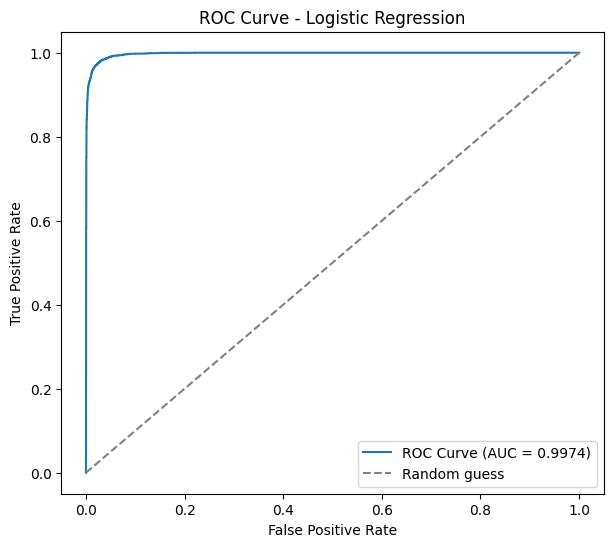

AUC: 0.9974466813855773


In [62]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_clf_test, y_pred_proba)
auc = roc_auc_score(y_clf_test, y_pred_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

print("AUC:", auc)

In [64]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_list = [0.30,0.40, 0.50, 0.60, 0.70]
results = []
for t in threshold_list:
  preds_at_t = (y_pred_proba >= t).astype(int)
  p = precision_score(y_clf_test, preds_at_t)
  r = recall_score(y_clf_test, preds_at_t)
  f1 = f1_score(y_clf_test, preds_at_t)
  results.append({'threshold': t, 'Precision': p, 'Recall': r, 'F1':f1})

result_df = pd.DataFrame(results)
print(result_df)

   threshold  Precision    Recall        F1
0        0.3   0.956568  0.988548  0.972295
1        0.4   0.969858  0.980606  0.975202
2        0.5   0.978063  0.971740  0.974891
3        0.6   0.985044  0.961027  0.972887
4        0.7   0.989000  0.946620  0.967346


In [65]:
# task- 6
log_reg_strong = LogisticRegression(C=0.01, max_iter=1000)
log_reg_strong.fit(X_train_scaled, y_clf_train)

y_pred_clf_strong = log_reg_strong.predict(X_test_scaled)
y_pred_proba_strong = log_reg_strong.predict_proba(X_test_scaled)[:, 1]

precision_strong = precision_score(y_clf_test, y_pred_clf_strong)
recall_strong = recall_score(y_clf_test, y_pred_clf_strong)
auc_strong = roc_auc_score(y_clf_test, y_pred_proba_strong)

# baseline (C=1.0) values for comparison
precision_base = precision_score(y_clf_test, y_pred_clf)
recall_base = recall_score(y_clf_test, y_pred_clf)
auc_base = roc_auc_score(y_clf_test, y_pred_proba)

comparison = pd.DataFrame({
    'Model': ['Logistic Regression (C=1.0)', 'Logistic Regression (C=0.01)'],
    'Precision': [precision_base, precision_strong],
    'Recall': [recall_base, recall_strong],
    'AUC': [auc_base, auc_strong]
})
print(comparison)

                          Model  Precision    Recall       AUC
0   Logistic Regression (C=1.0)   0.978063  0.971740  0.997447
1  Logistic Regression (C=0.01)   0.977687  0.971186  0.997209


In [69]:
# bootstrap confidence interval for auc difference.
n_bootstraps = 500
auc_diffs = []

y_clf_test_array = y_clf_test.values

for i in range(n_bootstraps):
    indices = np.random.choice(len(y_clf_test_array), size=len(y_clf_test_array), replace=True)

    y_sample = y_clf_test_array[indices]
    proba_base_sample = y_pred_proba[indices]
    proba_strong_sample = y_pred_proba_strong[indices]

    auc_base_sample = roc_auc_score(y_sample, proba_base_sample)
    auc_strong_sample = roc_auc_score(y_sample, proba_strong_sample)

    auc_diffs.append(auc_base_sample - auc_strong_sample)

auc_diffs = np.array(auc_diffs)

mean_diff = np.mean(auc_diffs)
lower_ci = np.percentile(auc_diffs, 2.5)
upper_ci = np.percentile(auc_diffs, 97.5)

print("Mean AUC difference:", mean_diff)
print("95% CI lower bound:", lower_ci)
print("95% CI upper bound:", upper_ci)


Mean AUC difference: 0.00023923532079166577
95% CI lower bound: 6.103830882363548e-05
95% CI upper bound: 0.0005062263221040974
